# kSZ Non-Gaussianity from Coeval Boxes

Measure skewness and PDF of kSZ maps as a function of neutral fraction,
using GRIZZLY coeval boxes (1D radiative transfer, 51 snapshots z=6–12).

Focus on **PDF** and **skewness** — the lowest-order non-Gaussianity
not captured by trispectrum methods.

## Why coeval boxes and not lightcones?

A lightcone tiles the same simulation box multiple times along the LOS. For a 300 Mpc
box spanning z=5–35 (~8000 comoving Mpc), the box repeats ~27 times. This creates two
problems for measuring non-Gaussianity:

1. **Without rotation:** Periodic repetition of the same structure creates artificial
   correlations and spurious non-Gaussianity from coherent bubble patterns repeating.

2. **With rotation (wrapper method):** Random box shifts every N slices break the
   periodicity, but also decorrelate the real bubble structure. Each tile becomes
   effectively independent, so the LOS sum averages over ~27 independent draws of the
   same field → **central limit theorem** drives the projected map toward Gaussian,
   regardless of the intrinsic non-Gaussianity of the field.

   Concretely: if you sum N independent maps with the same distribution, the skewness
   of the sum scales as ~1/√N. With ~27 tiles, skewness is suppressed by a factor ~5.

**Neither is physical.** In reality each LOS passes through a unique volume of the
universe — there is no repetition and no random shifting. The lightcone projection
through genuinely correlated large-scale structure preserves non-Gaussianity.

## Why coeval cubes don't have this problem

A coeval box is a single snapshot of the universe at one redshift. When we project
the kSZ integrand along one axis, we are summing through **one continuous, self-consistent
volume** — no repetition, no stitching, no rotation.

Every cell along the LOS is part of the same realization: the density, velocity, and
ionization fields are spatially correlated as they should be. The bubble geometry is
preserved exactly. If a large ionized bubble creates a coherent velocity-weighted dipole
pattern, that shows up faithfully in the projected kSZ map.

The tradeoff:
- **Lightcone:** long LOS (~8000 Mpc) but corrupted by tiling artifacts
- **Coeval:** short LOS (one box, ~500–700 Mpc) but clean non-Gaussianity measurement

For measuring how non-Gaussianity depends on xHI, the coeval approach is ideal:
each snapshot gives one (z, xHI, skewness) data point with no cross-contamination
between epochs.

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import gc

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

## 1. kSZ projection from a single coeval box

For a coeval box at redshift z, the kSZ map is:

$$\Delta T_{\rm kSZ} = -T_{\rm CMB} \, \sigma_T \, n_{e,0} \, (1+z)^3 \, \frac{\Delta l}{c} \sum_{\rm LOS} x_e \, (1+\delta) \, v_z$$

Summed along one axis. No tiling, no rotation, no cumulative τ — clean measurement.

In [11]:
# ── Physical constants ──
_SIGMA_T   = 6.6524587158e-25   # Thomson cross-section [cm²]
_C_CM_S    = 2.99792458e10      # speed of light [cm/s]
_T_CMB     = 2.725e6            # CMB temperature [µK]
_M_P       = 1.6726219e-24      # proton mass [g]
_MPC_TO_CM = 3.085677581e24     # Mpc → cm


def compute_ksz_coeval(vz, xHI, density, z, box_len, n_cells,
                        h=0.6736, omega_b=0.049, vel_in_cm_s=False):
    """Compute kSZ map from a single coeval box by summing along axis=2.
    
    ΔT_kSZ = -T_CMB * σ_T * n_e(z) * dl * Σ[ x_e * (1+δ) * v_z/c ]
    
    Parameters
    ----------
    vz : (N,N,N) velocity field. If vel_in_cm_s=True, in cm/s (GRIZZLY).
         If False, in Mpc units (21cmFAST comoving peculiar displacement).
    xHI : (N,N,N) neutral fraction
    density : (N,N,N) density field. If mean~1: rho/rho_bar. If mean~0: overdensity.
    """
    Y_He = 0.24
    rho_crit_0 = 1.8788e-29 * h**2
    n_e_0 = rho_crit_0 * omega_b / _M_P * (1.0 + (1.0 - Y_He)) / 2.0
    n_e_z = n_e_0 * (1.0 + z)**3
    dl_cm = (box_len / (1.0 + z)) / n_cells * _MPC_TO_CM
    
    # Prefactor: -T_CMB * σ_T * n_e * dl  (v/c goes in the integrand)
    pref = -_T_CMB * _SIGMA_T * n_e_z * dl_cm
    
    x_e = 1.0 - np.clip(xHI, 0.0, 1.0)
    
    if density.mean() > 0.5:
        delta = density / density.mean() - 1.0
    else:
        delta = density
    
    if vel_in_cm_s:
        v_over_c = vz / _C_CM_S
    else:
        a = 1.0 / (1.0 + z)
        v_over_c = a * vz * _MPC_TO_CM / _C_CM_S
    
    integrand = x_e * (1.0 + delta) * v_over_c
    ksz_map = pref * np.sum(integrand, axis=2)
    return ksz_map.astype(np.float32)


print("kSZ coeval projection defined.")

kSZ coeval projection defined.


## 2. GRIZZLY — true coeval boxes (1D radiative transfer)

In [12]:
# ── GRIZZLY data readers ──
import glob, os, re

DATA_GRIZ = "../data_grizzly/"
N_CELL_GRIZ = 600
BOX_MPC_H = 500.0
H_GRIZ = 0.7
BOX_LEN_GRIZ = BOX_MPC_H / H_GRIZ
CROP = slice(30, 570)
N_CROP = 540
BOX_CROP = BOX_LEN_GRIZ * N_CROP / N_CELL_GRIZ
NC_PM = 13824
OMEGA_M_GRIZ = 0.27
OMEGA_B_GRIZ = 0.045
XHI_PAT = "zeta0.389fesc0.389_Mmin0.120E+10_MminX0.120E+10_fx0.100E+03_sed3_al1.200xhi.bin"

def read_den(filename, n=N_CELL_GRIZ):
    with open(filename, 'rb') as f:
        f.seek(12)
        data = np.fromfile(f, dtype=np.dtype('<f4'), count=n**3)
    return data.reshape((n, n, n), order='F')

def read_xhi(filename, n=N_CELL_GRIZ):
    with open(filename, 'rb') as f:
        data = np.fromfile(f, dtype=np.float32, count=n**3)
    return data.reshape((n, n, n), order='F')

def read_vz(z, den, filename, n=N_CELL_GRIZ, box=BOX_MPC_H, nc=NC_PM, h=H_GRIZ):
    Mpc_cm = 3.08568025e24
    Ho = h * 3.2407e-18
    with open(filename, 'rb') as f:
        f.seek(12)
        arrv3 = np.fromfile(f, dtype=np.dtype('<f4'), count=3*n**3)
    arrv3 = arrv3.reshape((3, n, n, n), order='F')
    len_unit = box * Mpc_cm / h / (1+z) / float(nc)
    tau_t = 2.0 / 3.0 / np.sqrt(OMEGA_M_GRIZ * Ho**2) / (1+z)**2
    vel_unit = len_unit / tau_t
    arrv3 *= np.float32(vel_unit * 8.0)
    den_safe = np.where(den > 1e-12, den, 1e-12)
    vz = (arrv3[2] / den_safe).astype(np.float32)
    del arrv3
    return vz  # cm/s

# Find all redshifts
den_files = sorted(glob.glob(DATA_GRIZ + "*n_all.dat"))
z_griz_all = np.sort([float(re.search(r'([\d.]+)n_all', f).group(1)) for f in den_files])
print(f"GRIZZLY: {len(z_griz_all)} snapshots, z = {z_griz_all.min():.3f}–{z_griz_all.max():.3f}")
print(f"Box: {BOX_CROP:.1f} Mpc (cropped), {N_CROP}³ cells")

GRIZZLY: 51 snapshots, z = 6.056–12.048
Box: 642.9 Mpc (cropped), 540³ cells


In [13]:
# ── Process each GRIZZLY coeval box ──
griz_results = []

for z in z_griz_all:
    den_full = read_den(DATA_GRIZ + f"{z:.3f}n_all.dat")
    xhi = read_xhi(DATA_GRIZ + f"{z:.3f}{XHI_PAT}")[CROP, CROP, CROP]
    vz = read_vz(z, den_full, DATA_GRIZ + f"{z:.3f}v_all.dat")[CROP, CROP, CROP]
    den = den_full[CROP, CROP, CROP]
    del den_full
    
    mean_xhi = xhi.mean()
    
    ksz_map = compute_ksz_coeval(
        vz, xhi, den, z, BOX_CROP, N_CROP,
        h=H_GRIZ, omega_b=OMEGA_B_GRIZ, vel_in_cm_s=True,
    )
    
    flat = (ksz_map - ksz_map.mean()).ravel().astype(np.float64)
    sigma = flat.std()
    skew = stats.skew(flat)
    kurt = stats.kurtosis(flat)
    
    griz_results.append({
        'z': z, 'mean_xHI': mean_xhi,
        'std': sigma, 'skewness': skew, 'kurtosis': kurt,
        'ksz_map': ksz_map,
    })
    print(f"  z={z:.3f}, <xHI>={mean_xhi:.3f}, std={sigma:.4e} µK, skew={skew:.3f}")
    
    del den, xhi, vz
    gc.collect()

print(f"\nDone: {len(griz_results)} GRIZZLY coeval boxes processed.")

  z=6.056, <xHI>=0.000, std=1.7370e+00 µK, skew=-0.090
  z=6.113, <xHI>=0.018, std=1.7754e+00 µK, skew=-0.063
  z=6.172, <xHI>=0.068, std=1.8633e+00 µK, skew=-0.035
  z=6.231, <xHI>=0.116, std=1.9417e+00 µK, skew=-0.053
  z=6.292, <xHI>=0.162, std=1.9959e+00 µK, skew=-0.066
  z=6.354, <xHI>=0.207, std=2.0366e+00 µK, skew=-0.070
  z=6.418, <xHI>=0.246, std=2.0627e+00 µK, skew=-0.068
  z=6.483, <xHI>=0.288, std=2.0770e+00 µK, skew=-0.061
  z=6.549, <xHI>=0.326, std=2.0828e+00 µK, skew=-0.051
  z=6.617, <xHI>=0.362, std=2.0814e+00 µK, skew=-0.044
  z=6.686, <xHI>=0.400, std=2.0731e+00 µK, skew=-0.039
  z=6.757, <xHI>=0.431, std=2.0634e+00 µK, skew=-0.033
  z=6.830, <xHI>=0.466, std=2.0457e+00 µK, skew=-0.027
  z=6.905, <xHI>=0.495, std=2.0271e+00 µK, skew=-0.022
  z=6.981, <xHI>=0.526, std=2.0000e+00 µK, skew=-0.016
  z=7.059, <xHI>=0.554, std=1.9713e+00 µK, skew=-0.011
  z=7.139, <xHI>=0.584, std=1.9379e+00 µK, skew=-0.006
  z=7.221, <xHI>=0.610, std=1.9012e+00 µK, skew=-0.001
  z=7.305,

## 3. Skewness vs neutral fraction

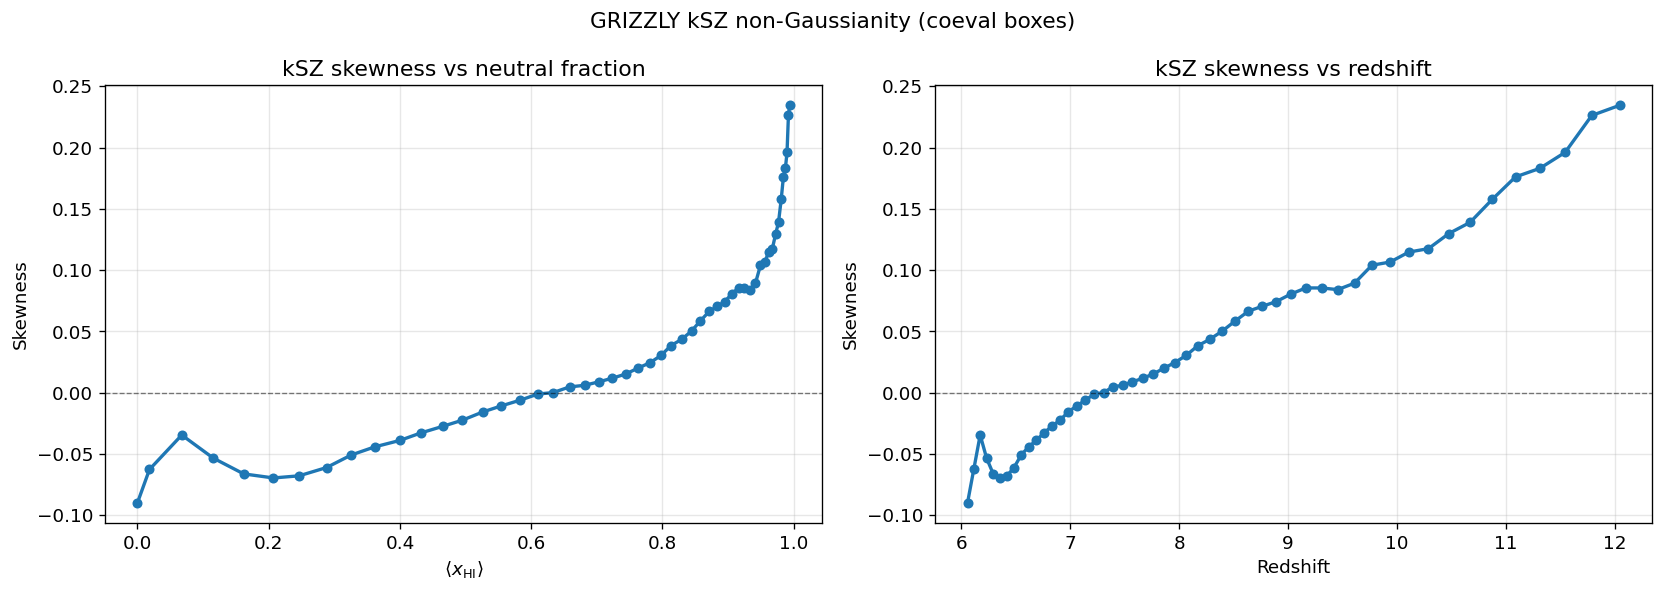

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

xhi_g = [r['mean_xHI'] for r in griz_results]
skew_g = [r['skewness'] for r in griz_results]
z_g = [r['z'] for r in griz_results]

# ── Left: Skewness vs xHI ──
ax = axes[0]
ax.plot(xhi_g, skew_g, 'o-', color='C0', ms=5, lw=2)
ax.axhline(0, color='k', ls='--', lw=0.8, alpha=0.5)
ax.set_xlabel(r'$\langle x_{\rm HI} \rangle$')
ax.set_ylabel('Skewness')
ax.set_title('kSZ skewness vs neutral fraction')
ax.grid(True, alpha=0.3)

# ── Right: Skewness vs redshift ──
ax = axes[1]
ax.plot(z_g, skew_g, 'o-', color='C0', ms=5, lw=2)
ax.axhline(0, color='k', ls='--', lw=0.8, alpha=0.5)
ax.set_xlabel('Redshift')
ax.set_ylabel('Skewness')
ax.set_title('kSZ skewness vs redshift')
ax.grid(True, alpha=0.3)

plt.suptitle('GRIZZLY kSZ non-Gaussianity (coeval boxes)', fontsize=13)
plt.tight_layout()
plt.show()

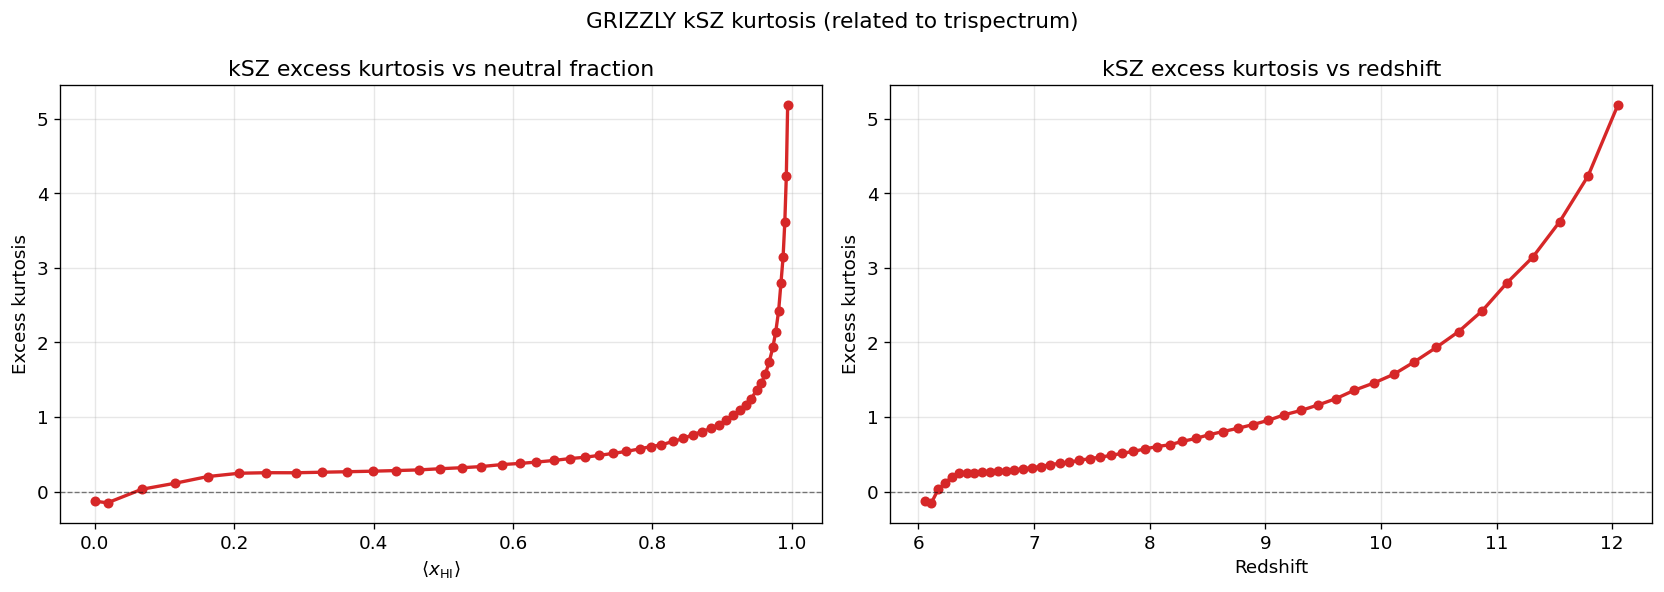

In [15]:
# ── Excess kurtosis vs xHI and redshift ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

kurt_g = [r['kurtosis'] for r in griz_results]

# ── Left: Kurtosis vs xHI ──
ax = axes[0]
ax.plot(xhi_g, kurt_g, 'o-', color='C3', ms=5, lw=2)
ax.axhline(0, color='k', ls='--', lw=0.8, alpha=0.5)
ax.set_xlabel(r'$\langle x_{\rm HI} \rangle$')
ax.set_ylabel('Excess kurtosis')
ax.set_title('kSZ excess kurtosis vs neutral fraction')
ax.grid(True, alpha=0.3)

# ── Right: Kurtosis vs redshift ──
ax = axes[1]
ax.plot(z_g, kurt_g, 'o-', color='C3', ms=5, lw=2)
ax.axhline(0, color='k', ls='--', lw=0.8, alpha=0.5)
ax.set_xlabel('Redshift')
ax.set_ylabel('Excess kurtosis')
ax.set_title('kSZ excess kurtosis vs redshift')
ax.grid(True, alpha=0.3)

plt.suptitle('GRIZZLY kSZ kurtosis (related to trispectrum)', fontsize=13)
plt.tight_layout()
plt.show()


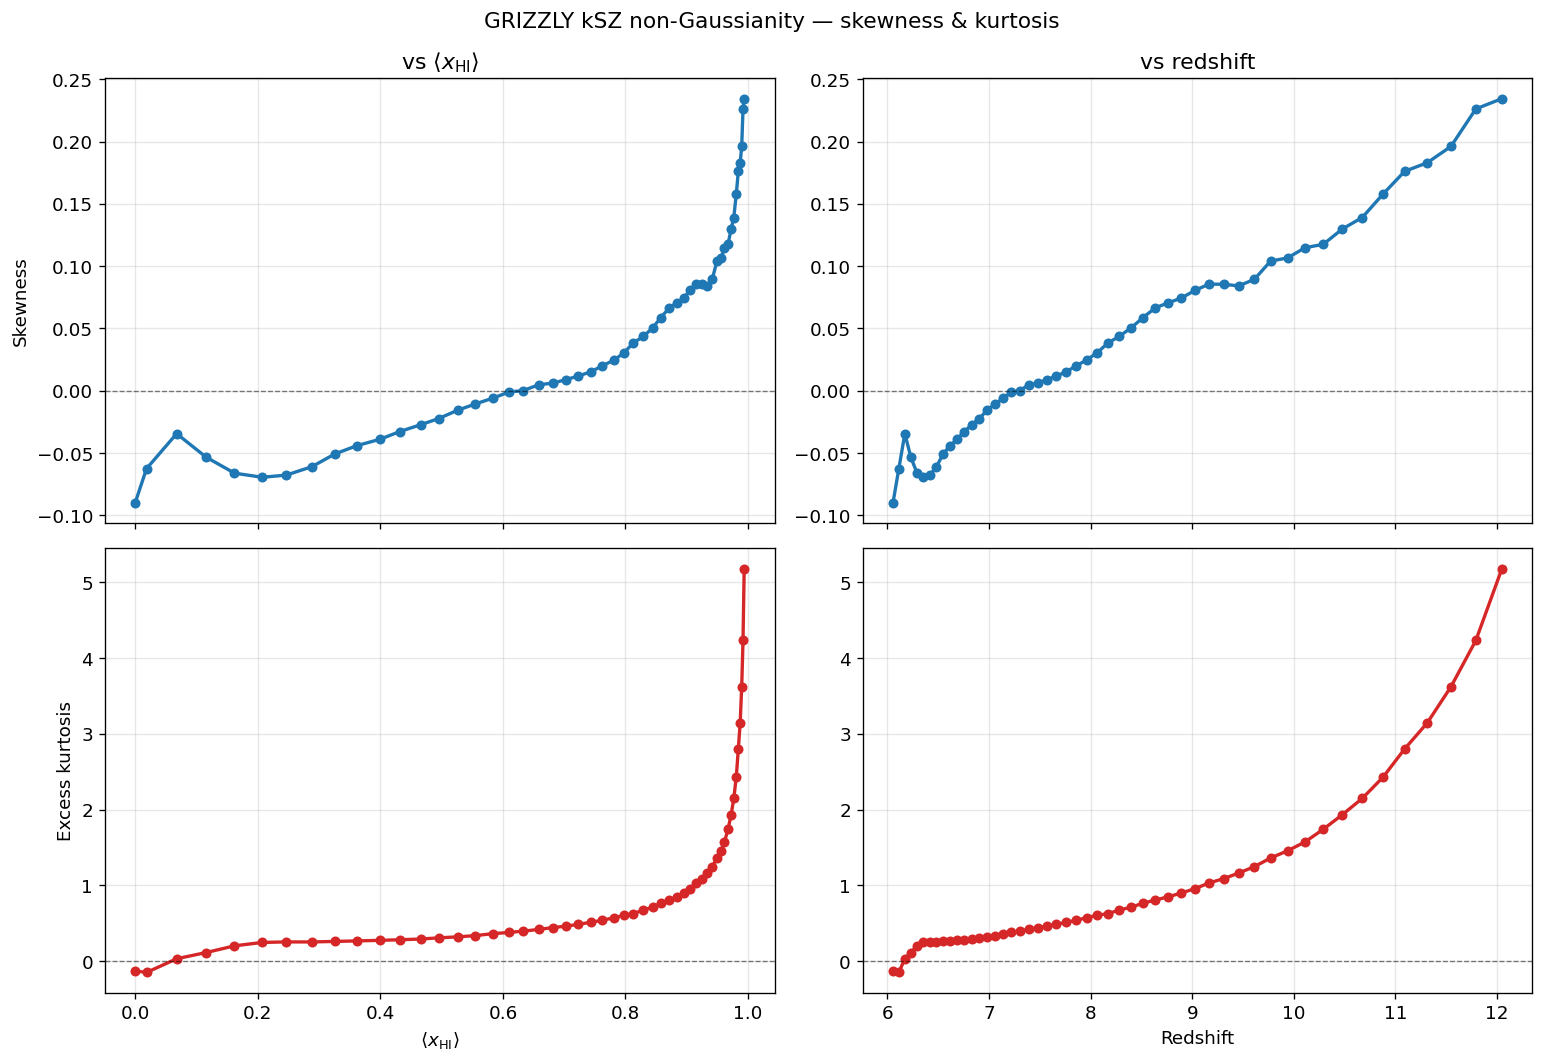

In [16]:
# ── Combined skewness + kurtosis overview ──
fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex='col')

# Top-left: skew vs xHI
axes[0, 0].plot(xhi_g, skew_g, 'o-', color='C0', ms=5, lw=2)
axes[0, 0].axhline(0, color='k', ls='--', lw=0.8, alpha=0.5)
axes[0, 0].set_ylabel('Skewness')
axes[0, 0].set_title(r'vs $\langle x_{\rm HI} \rangle$')
axes[0, 0].grid(True, alpha=0.3)

# Top-right: skew vs z
axes[0, 1].plot(z_g, skew_g, 'o-', color='C0', ms=5, lw=2)
axes[0, 1].axhline(0, color='k', ls='--', lw=0.8, alpha=0.5)
axes[0, 1].set_title('vs redshift')
axes[0, 1].grid(True, alpha=0.3)

# Bottom-left: kurt vs xHI
axes[1, 0].plot(xhi_g, kurt_g, 'o-', color='C3', ms=5, lw=2)
axes[1, 0].axhline(0, color='k', ls='--', lw=0.8, alpha=0.5)
axes[1, 0].set_xlabel(r'$\langle x_{\rm HI} \rangle$')
axes[1, 0].set_ylabel('Excess kurtosis')
axes[1, 0].grid(True, alpha=0.3)

# Bottom-right: kurt vs z
axes[1, 1].plot(z_g, kurt_g, 'o-', color='C3', ms=5, lw=2)
axes[1, 1].axhline(0, color='k', ls='--', lw=0.8, alpha=0.5)
axes[1, 1].set_xlabel('Redshift')
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('GRIZZLY kSZ non-Gaussianity — skewness & kurtosis', fontsize=13)
plt.tight_layout()
plt.show()


## 4. PDFs at selected neutral fractions

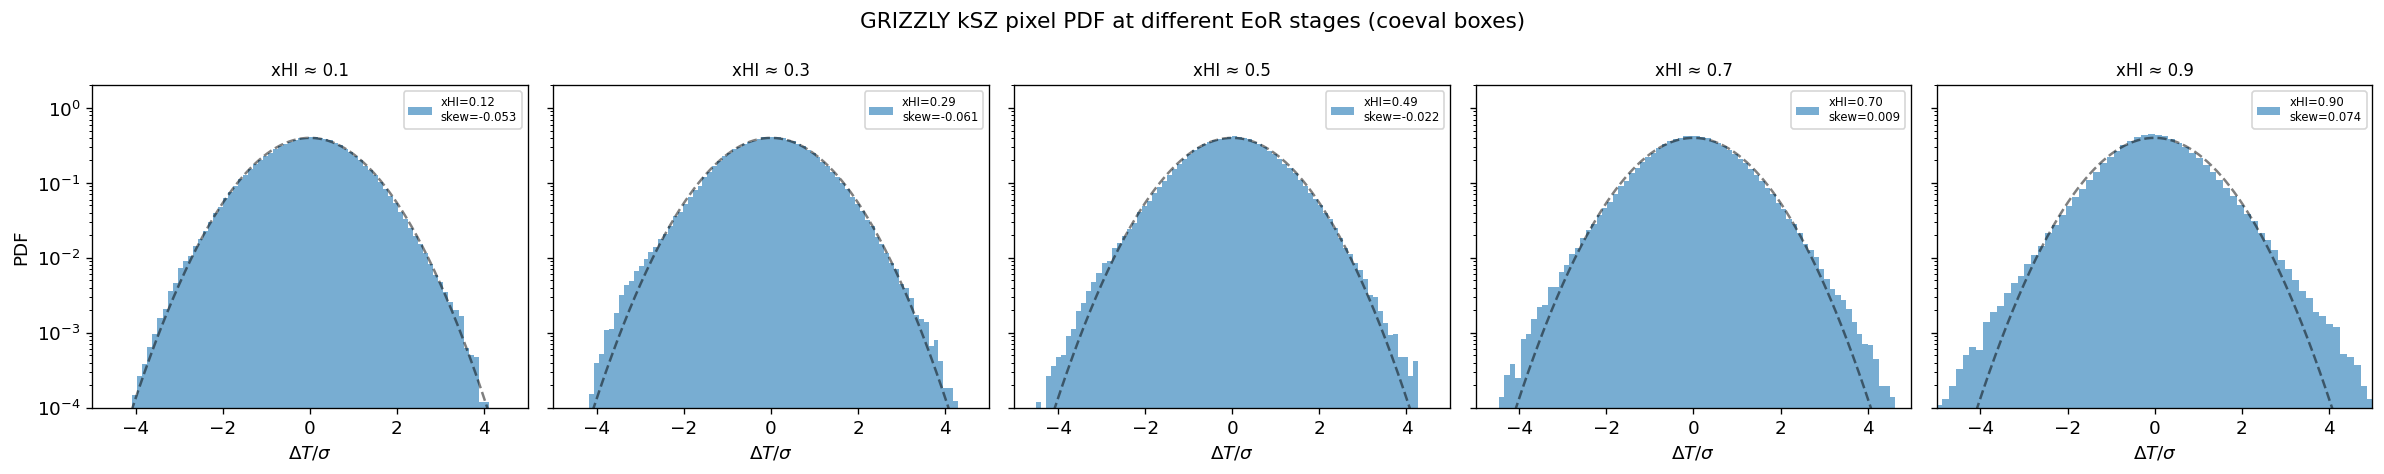

In [17]:
target_xHI = [0.1, 0.3, 0.5, 0.7, 0.9]

def find_closest(results, target):
    xhi_arr = np.array([r['mean_xHI'] for r in results])
    idx = np.argmin(np.abs(xhi_arr - target))
    return results[idx]

fig, axes = plt.subplots(1, len(target_xHI), figsize=(4*len(target_xHI), 4),
                          sharey=True)

x_gauss = np.linspace(-5, 5, 300)

for ax, t_xhi in zip(axes, target_xHI):
    rg = find_closest(griz_results, t_xhi)
    flat_g = rg['ksz_map'].ravel().astype(np.float64)
    if flat_g.std() > 0:
        flat_g = (flat_g - flat_g.mean()) / flat_g.std()
        ax.hist(flat_g, bins=80, density=True, alpha=0.6, color='C0',
                histtype='stepfilled',
                label=f"xHI={rg['mean_xHI']:.2f}\nskew={rg['skewness']:.3f}")
    
    ax.plot(x_gauss, stats.norm.pdf(x_gauss), 'k--', lw=1.5, alpha=0.5)
    ax.set_xlabel(r'$\Delta T / \sigma$')
    ax.set_title(f'xHI ≈ {t_xhi}', fontsize=10)
    ax.set_yscale('log')
    ax.set_ylim(1e-4, 2)
    ax.set_xlim(-5, 5)
    ax.legend(fontsize=7)

axes[0].set_ylabel('PDF')
plt.suptitle('GRIZZLY kSZ pixel PDF at different EoR stages (coeval boxes)', fontsize=13)
plt.tight_layout()
plt.show()

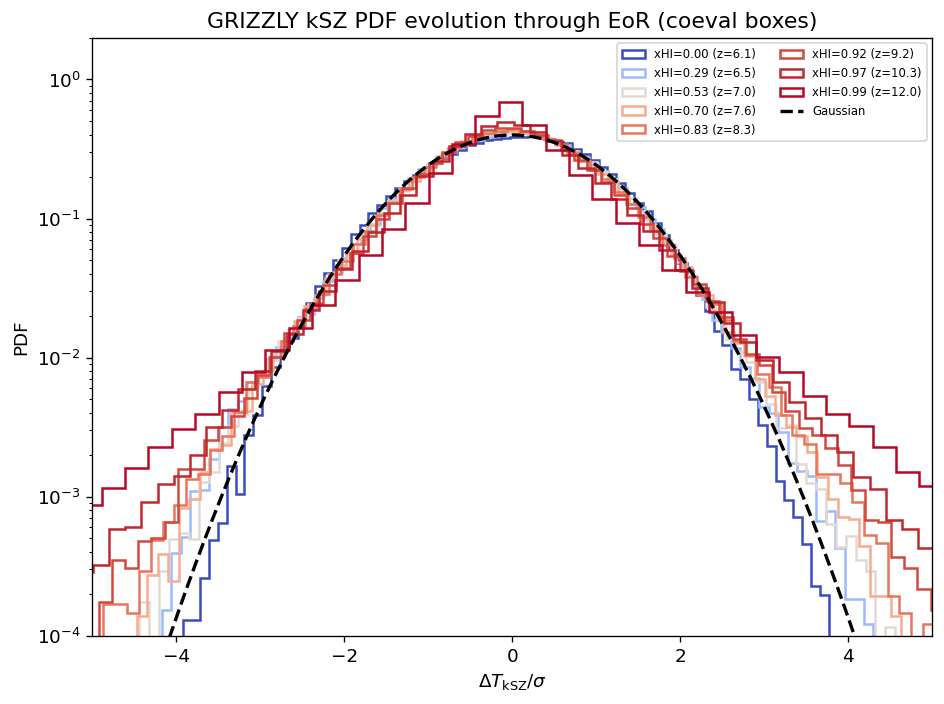

In [18]:
# ── Overlay PDFs colored by xHI ──
fig, ax = plt.subplots(figsize=(8, 6))

cmap = plt.cm.coolwarm
# Pick ~8 evenly spaced GRIZZLY snapshots
n_show = min(8, len(griz_results))
indices = np.linspace(0, len(griz_results)-1, n_show, dtype=int)

for idx in indices:
    r = griz_results[idx]
    flat = r['ksz_map'].ravel().astype(np.float64)
    flat = (flat - flat.mean()) / flat.std()
    color = cmap(r['mean_xHI'])
    ax.hist(flat, bins=80, density=True, histtype='step', lw=1.5,
            color=color, label=f"xHI={r['mean_xHI']:.2f} (z={r['z']:.1f})")

ax.plot(x_gauss, stats.norm.pdf(x_gauss), 'k--', lw=2, label='Gaussian')
ax.set_xlabel(r'$\Delta T_{\rm kSZ} / \sigma$')
ax.set_ylabel('PDF')
ax.set_yscale('log')
ax.set_ylim(1e-4, 2)
ax.set_xlim(-5, 5)
ax.legend(fontsize=7, ncol=2)
ax.set_title('GRIZZLY kSZ PDF evolution through EoR (coeval boxes)')
plt.tight_layout()
plt.show()

## 5. Example kSZ maps at key EoR stages

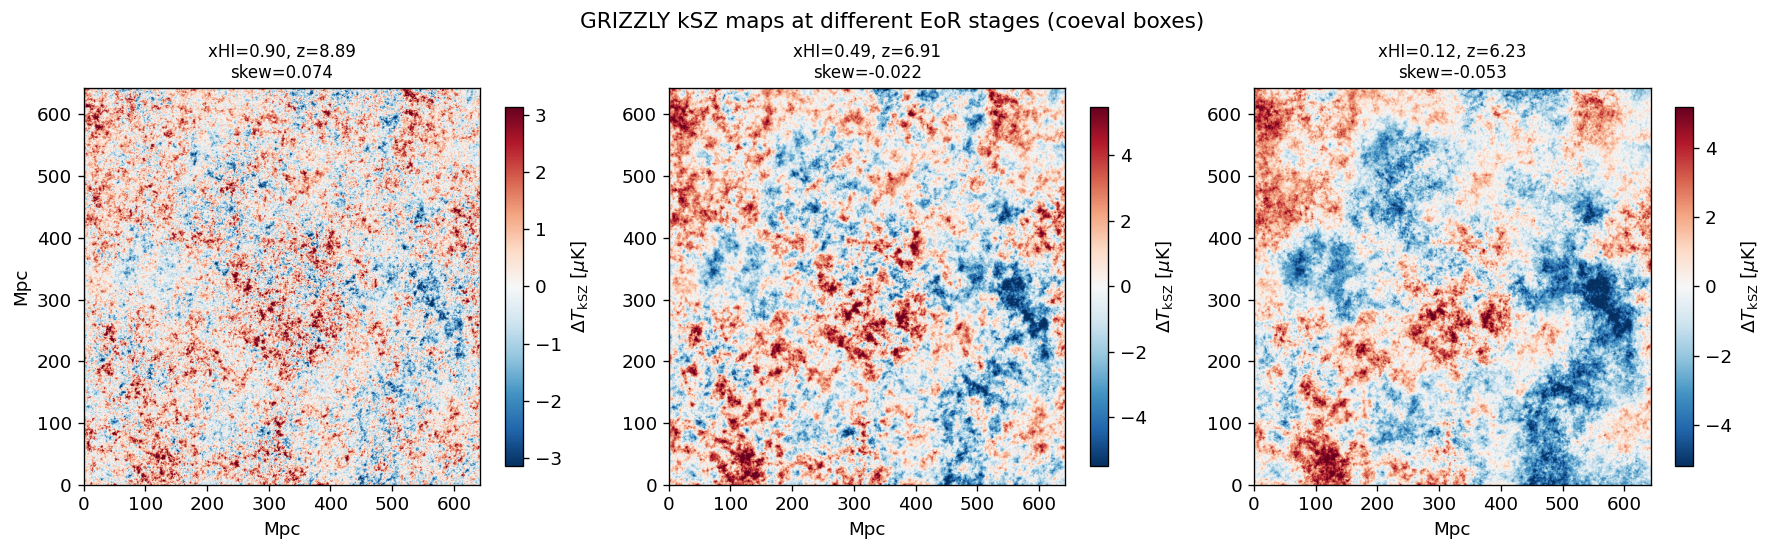

In [19]:
# ── Show maps at 3 EoR stages ──
stages = [0.9, 0.5, 0.1]
fig, axes = plt.subplots(1, len(stages), figsize=(5*len(stages), 4.5))

for ax, t_xhi in zip(axes, stages):
    r = find_closest(griz_results, t_xhi)
    m = r['ksz_map']
    vmax = np.percentile(np.abs(m), 99)
    if vmax == 0:
        vmax = 1
    im = ax.imshow(m, cmap='RdBu_r', origin='lower',
                   extent=[0, BOX_CROP, 0, BOX_CROP],
                   vmin=-vmax, vmax=vmax)
    ax.set_title(f"xHI={r['mean_xHI']:.2f}, z={r['z']:.2f}\n"
                 f"skew={r['skewness']:.3f}", fontsize=10)
    ax.set_xlabel('Mpc')
    plt.colorbar(im, ax=ax, label=r'$\Delta T_{\rm kSZ}$ [$\mu$K]', shrink=0.8)

axes[0].set_ylabel('Mpc')
plt.suptitle('GRIZZLY kSZ maps at different EoR stages (coeval boxes)', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Integrated (total) kSZ: sum across all snapshots

Stack the per-snapshot kSZ maps into a single integrated map — this is what an observer
would actually see (modulo tiling/rotation). Compare its non-Gaussianity to the per-snapshot values.


Integrated kSZ map:
  std            = 6.1624e+01 µK
  skewness       = -0.0188
  excess kurtosis= 0.4166
  N snapshots    = 51


/var/folders/90/xdq542m92j92bx1klmldh0l40000gn/T/ipykernel_99275/1320465613.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


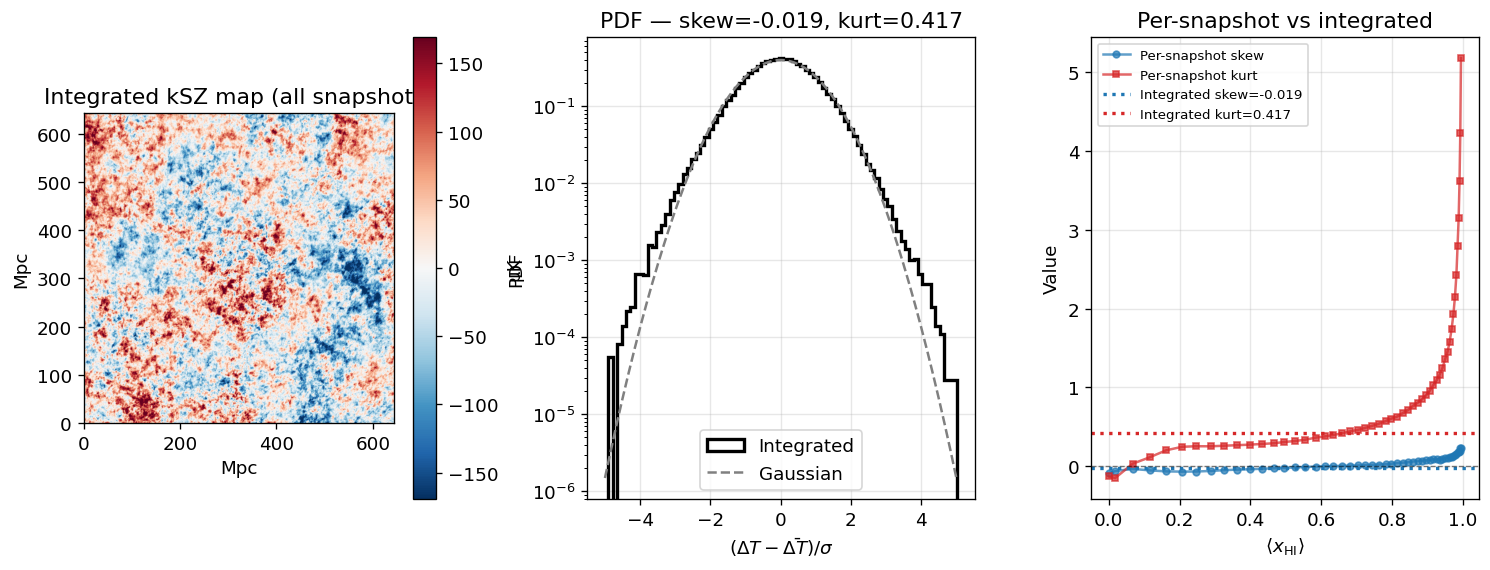

In [20]:
# ── Sum all per-snapshot kSZ maps into one integrated map ──
ksz_integrated = np.sum([r['ksz_map'] for r in griz_results], axis=0)

flat_int = (ksz_integrated - ksz_integrated.mean()).ravel().astype(np.float64)
sigma_int = flat_int.std()
skew_int = stats.skew(flat_int)
kurt_int = stats.kurtosis(flat_int)

print(f'Integrated kSZ map:')
print(f'  std            = {sigma_int:.4e} µK')
print(f'  skewness       = {skew_int:.4f}')
print(f'  excess kurtosis= {kurt_int:.4f}')
print(f'  N snapshots    = {len(griz_results)}')

# ── Figure: map + PDF + per-snapshot comparison ──
fig = plt.figure(figsize=(15, 5))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1], wspace=0.3)

# Integrated kSZ map
ax0 = fig.add_subplot(gs[0, 0])
vmax = np.percentile(np.abs(ksz_integrated), 99)
im = ax0.imshow(ksz_integrated, cmap='RdBu_r', origin='lower',
                extent=[0, BOX_CROP, 0, BOX_CROP],
                vmin=-vmax, vmax=vmax)
ax0.set_title('Integrated kSZ map (all snapshots)')
ax0.set_xlabel('Mpc'); ax0.set_ylabel('Mpc')
plt.colorbar(im, ax=ax0, label='µK')

# PDF: integrated vs Gaussian
ax1 = fig.add_subplot(gs[0, 1])
flat_norm = flat_int / sigma_int
x_g = np.linspace(-5, 5, 300)
ax1.hist(flat_norm, bins=80, density=True, histtype='step',
         color='k', lw=2, label='Integrated')
ax1.plot(x_g, np.exp(-x_g**2 / 2) / np.sqrt(2*np.pi),
         '--', color='grey', label='Gaussian')
ax1.set_yscale('log')
ax1.set_xlabel(r'$(\Delta T - \bar{\Delta T}) / \sigma$')
ax1.set_ylabel('PDF')
ax1.set_title(f'PDF — skew={skew_int:.3f}, kurt={kurt_int:.3f}')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Per-snapshot vs integrated comparison
ax2 = fig.add_subplot(gs[0, 2])
ax2.plot(xhi_g, skew_g, 'o-', color='C0', ms=4, lw=1.5,
         label='Per-snapshot skew', alpha=0.7)
ax2.plot(xhi_g, kurt_g, 's-', color='C3', ms=4, lw=1.5,
         label='Per-snapshot kurt', alpha=0.7)
ax2.axhline(skew_int, color='C0', ls=':', lw=2,
            label=f'Integrated skew={skew_int:.3f}')
ax2.axhline(kurt_int, color='C3', ls=':', lw=2,
            label=f'Integrated kurt={kurt_int:.3f}')
ax2.axhline(0, color='k', ls='--', lw=0.8, alpha=0.5)
ax2.set_xlabel(r'$\langle x_{\rm HI} \rangle$')
ax2.set_ylabel('Value')
ax2.set_title('Per-snapshot vs integrated')
ax2.legend(fontsize=8, loc='best')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
